In [ ]:
import pandas as pd
df = pd.read_csv('sme_risk_data.csv')
print(df.columns)

Index(['FQ1', 'Established_year', 'Type_SME', 'Sector', 'SME_Size', 'FL1',
       'FL2', 'FL3', 'FL4', 'FR1', 'FR2', 'FR3', 'FR4', 'RA1', 'RA2', 'RA3',
       'RA4', 'MDA1', 'MDA2', 'MDA3', 'MDA4', 'FDM1', 'FDM2', 'FDM3', 'FDM4',
       'FA1', 'FA2', 'FA3', 'FA4', 'FL_avg', 'FR_avg', 'RA_avg', 'FA_avg',
       'risk_score', 'risk_category'],
      dtype='object')


In [ ]:
risk_mapping = {
    'Low Risk': 0,
    'Medium Risk': 1,
    'High Risk': 2
}

df['Risk_Label'] = df['risk_category'].map(risk_mapping)

print(df[['risk_category', 'Risk_Label']].head())

  risk_category  Risk_Label
0   Medium Risk           1
1     High Risk           2
2   Medium Risk           1
3      Low Risk           0
4      Low Risk           0


In [ ]:
# Features (inputs to the model)

features = [
    'FL_avg',
    'FR_avg',
    'RA_avg',
    'FA_avg'
]

X = df[features]

# Target variable (what we want to predict)

y = df['Risk_Label']

print(X.head())
print(y.head())

   FL_avg  FR_avg  RA_avg  FA_avg
0     3.5     2.5     2.0     3.5
1     3.0     2.5     2.5     3.0
2     4.0     1.5     2.0     4.0
3     4.5     1.5     3.0     4.5
4     3.5     3.5     2.5     3.5
0    1
1    2
2    1
3    0
4    0
Name: Risk_Label, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data size:", len(X_train))
print("Testing data size:", len(X_test))

Training data size: 360
Testing data size: 90


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
y_pred = log_model.predict(X_test)

print(y_pred[:10])

[1 1 2 1 2 2 1 0 1 2]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

# Detailed report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9444444444444444

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       0.94      0.91      0.92        32
           2       0.90      0.93      0.91        28

    accuracy                           0.94        90
   macro avg       0.94      0.94      0.94        90
weighted avg       0.94      0.94      0.94        90



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions

rf_predictions = rf_model.predict(X_test)

# Accuracy

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

# Detailed report

print("\nClassification Report:\n")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.9333333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        30
           1       0.91      0.91      0.91        32
           2       0.93      0.93      0.93        28

    accuracy                           0.93        90
   macro avg       0.93      0.93      0.93        90
weighted avg       0.93      0.93      0.93        90



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance

importance = rf_model.feature_importances_

# Create dataframe

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sort values

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df)

  Feature  Importance
3  FA_avg    0.401777
0  FL_avg    0.207358
1  FR_avg    0.207300
2  RA_avg    0.183565


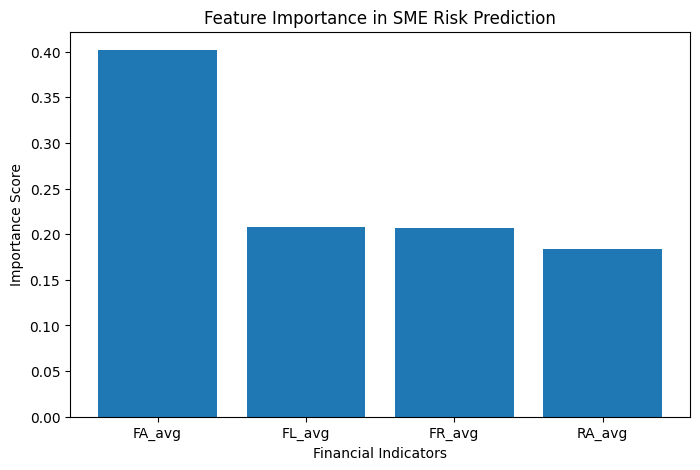

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance_df['Feature'],
    feature_importance_df['Importance']
)

plt.title('Feature Importance in SME Risk Prediction')

plt.xlabel('Financial Indicators')
plt.ylabel('Importance Score')

plt.show()

In [ ]:
df['Predicted_Risk'] = rf_model.predict(X)

In [ ]:
reverse_mapping = {
    0: 'Low',
    1: 'Medium',
    2: 'High'
}

df['Predicted_Risk'] = df['Predicted_Risk'].map(reverse_mapping)

In [ ]:
df.to_csv('sme_ml_predictions.csv', index=False)

print("File exported successfully.")

File exported successfully.


In [ ]:
from google.colab import files

files.download('sme_ml_predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>